# Tarea 1
# Análisis exploratorio de datos
## Catálogo sísmico global del USGS (1900–2025)

**Integrantes:** Josefina Yantén y Daniel Faúndez

**Dataset:** `earthquakes_usgs.csv` -> catálogo del U.S. Geological Survey

**Desafío inicial:** ¿Podemos afirmar, a partir de estos datos, que últimamente está temblando más?

---
## 1. Comprender la muestra: análisis preliminar de los datos.

Antes de  comenzar a analizar cualquier relación, necesitamos visualizar el archivo de datos, ver qué información nos entrega cada columna y qué podemos derivar de ellas filtrando también datos innecesarios, poco relevantes o aquellos que puedan entorpecer nuestro análisis.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

df = pd.read_csv('earthquakes_usgs.csv', index_col=0)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)
df['year'] = df['time'].dt.year

print("Dimensiones del catálogo:", df.shape)
df.head()

Dimensiones del catálogo: (310535, 13)


,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms,year
0,1900-01-05 19:00:00+00:00,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN,1900
1,1900-01-11 09:07:00+00:00,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN,1900
2,1900-01-20 06:33:00+00:00,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN,1900
3,1900-01-31 19:22:00+00:00,48.0,146.0,450.0,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN,1900
4,1900-04-30 22:41:14+00:00,36.9,-121.6,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN,1900


In [27]:
print("Rango temporal:", df.time.min().date(), "->", df.time.max().date())
print("\nTipos de evento registrados:")
print(df['type'].value_counts())

Rango temporal: 1900-01-05 -> 2026-08-26

Tipos de evento registrados:
type
earthquake           309821
nuclear explosion       614
volcanic eruption        71
explosion                16
mine collapse             6
rock burst                3
landslide                 2
other event               1
quarry blast              1
Name: count, dtype: int64


In [28]:
print("Valores faltantes (%):")
print((df.isna().mean()*100).round(2).sort_values(ascending=False))
print("\nEstadística descriptiva de las features numéricas principales:")
display(df[['mag','depth']].describe().round(2))

Valores faltantes (%):
nst          61.26
rms          16.11
depth         0.23
time          0.00
latitude      0.00
mag           0.00
longitude     0.00
magType       0.00
place         0.00
status        0.00
type          0.00
net           0.00
year          0.00
dtype: float64

Estadística descriptiva de las features numéricas principales:


,mag,depth
count,310535.00,309808.00
mean,4.93,68.74
std,0.48,114.97
min,3.38,-4.00
25%,4.60,10.00
50%,4.80,33.00
75%,5.10,60.20
max,9.50,700.90


- Gracias al analisis preliminar de la muestra, podemos notar que hay dos filtros que podemos generar que harán que el analisis posterior sea más efectivo.

  1. Descartaremos los eventos que no correspondan al type= "earthquake", ya que así solo analizaremos los eventos generados por movimitento tectónico y no causados por factores externos que no nos interesan estudiar.

  2. Descartaremos todos los datos del año 2026. Al no ser un año completado, puede producir una caída falsa en la cantidad de sismos por año al no estar considerando los 365 días, tal como si se considera en el resto de datos.

In [29]:
eq = df[(df['type'] == 'earthquake') & (df['year'] <= 2025)].copy()

print(f"Eventos no tectónicos descartados: {(df['type']!='earthquake').sum()}")
print(f"Eventos de 2026 (año incompleto) descartados: {((df['type']=='earthquake') & (df['year']==2026)).sum()}")
print(f"\nMuestra final: {len(eq):,} sismos entre {eq.year.min()} y {eq.year.max()}")
print(f"Magnitud mínima del catálogo: {eq.mag.min()} | máxima: {eq.mag.max()}")
print(f"\nEventos bajo M 4.5: {(eq.mag < 4.5).sum()}")

Eventos no tectónicos descartados: 714
Eventos de 2026 (año incompleto) descartados: 4937

Muestra final: 304,884 sismos entre 1900 y 2025
Magnitud mínima del catálogo: 3.38 | máxima: 9.5

Eventos bajo M 4.5: 1


### Qué aprendimos de la muestra

- Al analizar el catálogo sísmico global vemos que en este caso, una observación representa un evento sísmico localizado por la red. Es importante notar que la población en este caso no son solo los sismos que ocurrieron, sino que la población en este caso abarca todos los sismos que la red fue capaz de detectar, localizar y catalogar. 

  Cada sismo está descrito por distintas features, de las cuales tomaremos las principales y definimos a continuación:
  - `time`: Define cuándo ocurrió el sismo, con fecha y hora.
  - `latitude`, `longitude`, `depth`: Estas features definen la latitud, longitud y profundidad del sismo, las cuales corresponden a características numéricas continuas espaciales.
  - `mag`: Gracias a esta carcterística se puede conocer la magnitud del sismo en cuestión, siendo una característica numérica continua. 
  - `magType`, `type`, `status`, `net`, `place`: Corresponden a variables categóricas, de las cuales nos parece relevante definir "type", ya que gracias a esta se puede saber con certeza cuál fue la causa del movimiento registrado por la red y así poder aislar solo los causados por sismos (ya que son los que nos interesan analizar).
  - `nst`, `rms`: corresponden a variables numéricas, las cuales a pesar de no ser muy relevantes respecto al analisis que se emplea más adelante, las mencionamos porque son las que presentan mayor porcentaje de valores faltantes. "nst" falta en un 61% y "rms" en un 16%.

  Es importante mencionar que "nst" indica cuántos sismógrafos distintos registraron el evento de forma clara, por lo que es esperable que tenga tan alto porcentaje de datos faltantes al considerar que tenemos datos desde 1900 y no se tenía la tecnología que se tiene hoy.

  Respecto a ciertas limitaciones que podemos notar, vemos que se tiene un umbral de magnitudes desde 4.5 hacia arriba, por lo que se ignoran todos los sismos ocurridos bajo ese valor. Por otra parte, sabemos que estamos considerando 125 años completos (1900-2025), y que por eso mismo la probabilidad de que un sismo entre al catálogo depende de cuándo y dónde ocurrió, no solo de su tamaño; esto por la calidad de instrumentos que se tenía sobre todo en los años iniciales del catálogo.

---
## 2. Pregunta de investigación

> ¿El aumento en el número de sismos registrados entre 1900 y 2025 refleja un aumento real de la actividad sísmica global, o es consecuencia de la mejora en la capacidad de detección de la red? Y luego de responder lo anterior, ¿podemos decir que los megaterremotos (M ≥ 8,5) se distribuyen al azar en el tiempo y en el espacio, o presentan patrones que sugieran algún grado de predictibilidad?


---
## 3. Magnitud y distribución espacial

Sabemos que la superficie de la Tierra funciona como un enorme rompecabezas formado por placas tectónicas. Estas placas están en constante movimiento y cuando chocan, se separan o se rozan entre sí, liberan energía en forma de sismos. El siguiente gráfico muestra los terremotos registrados entre 1900 y 2025 pertenecientes al catálogo a análizar.

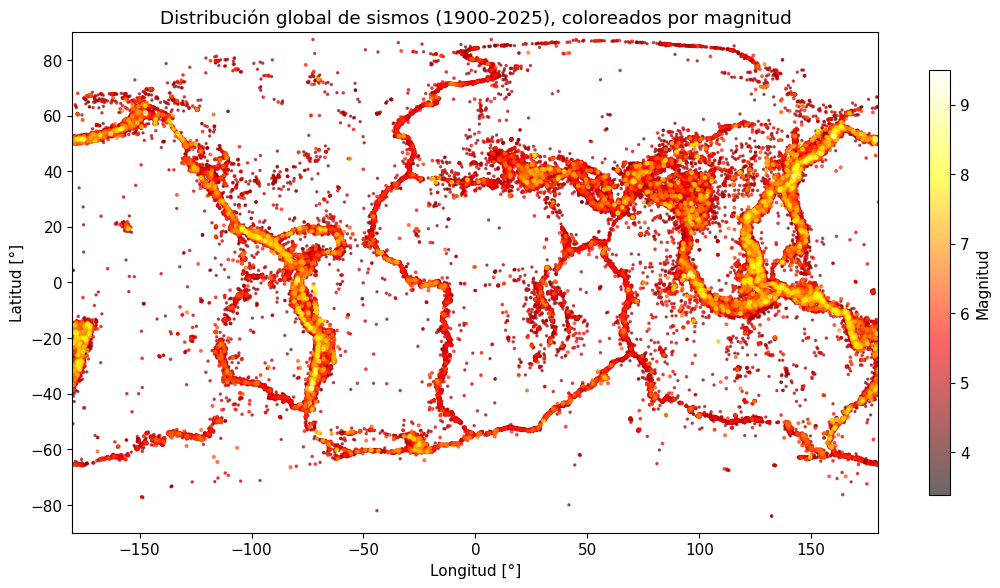

In [30]:
eq_sorted = eq.sort_values(by='mag', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6.5))

sc = ax.scatter(eq_sorted.longitude, eq_sorted.latitude, 
                c=eq_sorted['mag'], 
                s=(eq_sorted['mag']**2) * 0.1, 
                cmap='hot', 
                alpha=0.6, 
                vmin=eq_sorted['mag'].min(), 
                vmax=eq_sorted['mag'].max())


plt.colorbar(sc, label='Magnitud', shrink=0.85)

ax.set_xlabel('Longitud [°]')
ax.set_ylabel('Latitud [°]')
ax.set_title('Distribución global de sismos (1900-2025), coloreados por magnitud')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

plt.show()

 - Podemos ver cómo la ubicación de los sismos dibuja de forma natural los bordes de las placas tectónicas. Además, los colores más claros y brillantes destacan los lugares exactos donde se han liberado las mayores magnitudes de energía. Estos lugares de mayor densidad de puntos y de brillo, dominan en los bordes del oceano pacífico delineando el cinturón de fuego y zonas de ásia.


- A continuación, mostramos un resumen donde ordenamos la cantidad total de sismos separándolos por niveles. Cabe destacar que estos grupos fueron definidos bajo nuestro propio criterio, por lo que no buscan representar una escala oficial. La idea principal detrás de esto es responder a una duda bastante directa: ¿hay alguna regla que relacione la magnitud de un sismo con la cantidad de veces que ocurre? 

  Con esto de forma muy pasajera quisimos comprobar si los terremotos más grandes son naturalmente menos comunes o si, por el contrario, no hay ninguna tendencia clara y todo se da de forma completamente aleatoria.

In [31]:
bins_mag = [4.5, 5.0, 7.0, 8.5, 15.0]
etiquetas_mag = [
    'Leve [4.5-5.0)', 
    'Intermedio [5.0-7.0)', 
    'Fuerte [7.0-8.5)', 
    'Megaterremotos (>=8.5)'
]

eq['clase_mag'] = pd.cut(eq['mag'], bins=bins_mag, labels=etiquetas_mag, right=False)

resumen_mag = eq.groupby('clase_mag', observed=True).agg(
    n=('mag', 'size')
)

display(resumen_mag)

,n
clase_mag,
Leve [4.5-5.0),199814
Intermedio [5.0-7.0),103465
Fuerte [7.0-8.5),1587
Megaterremotos (>=8.5),17


##### - Focos de alta energía:

In [32]:
print("Regiones con más sismos fuertes (magnitud > 7.0):")
print(eq[eq.mag > 7.0].place.str.split(',').str[-1].str.strip().value_counts().head(6))

Regiones con más sismos fuertes (magnitud > 7.0):
place
Indonesia           111
Japan               105
Papua New Guinea     77
Philippines          73
Russia               67
Vanuatu              59
Name: count, dtype: int64


Con lo anterior, podemos evidenciar en la tabla una marcada relación inversa donde registramos casi 200.000 sismos leves frente a la poca cantidad de sismos fuertes (1.587 eventos), o frente a la poca cantidad de megaterremotos registrados (solo 17 eventos). Lo verdaderamente interesante es que estos sismos de gran magnitud (>7.0) no se distribuyen al azar durante los 125 años, sino que son regiones como Indonesia, Japón y sus países vecinos los que liberan la inmensa mayoría de esta energía de alta magnitud a nivel global.

---
## 4. Distribución de magnitudes a través del tiempo

Basándonos en la pregunta del desafío inicial, se planteó la hipotesis de que si la red mejoró, el efecto debería aparecer en la distribución de magnitudes. O sea, las épocas antiguas deberían perder los eventos de magnitudes menores.

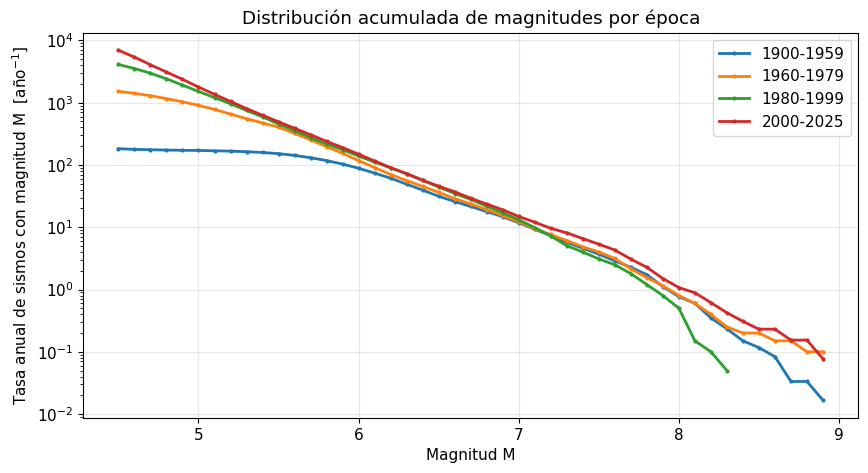

In [33]:
epocas = [
    (1900, 1959, '1900-1959'),
    (1960, 1979, '1960-1979'),
    (1980, 1999, '1980-1999'),
    (2000, 2025, '2000-2025')
]

fig, ax = plt.subplots(figsize=(10, 5)) 
mags = np.arange(4.5, 9.0, 0.1)

for lo, hi, lab in epocas:
    s = eq[(eq.year>=lo) & (eq.year<=hi)].mag
    N = np.array([(s >= m).sum() for m in mags]) / (hi - lo + 1) 
    ax.plot(mags[N>0], N[N>0], lw=2, marker='.', ms=4, label=lab)

ax.set_yscale('log')
ax.set_xlabel('Magnitud M')
ax.set_ylabel('Tasa anual de sismos con magnitud M  [año$^{-1}$]')
ax.set_title('Distribución acumulada de magnitudes por época')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Al analizar la distribución acumulada de magnitudes por época, vemos de primera la particularidad del comportamiento de la curva azul (entre 1900 y 1959) asociado a magnitudes bajas, por lo que surge la duda de si a medida que ha pasado el tiempo, ha ido aumentando la cantidad de sismos o simplemente hace 125 años no se tenía la capacidad sensible de registro que se tiene hoy en día. 

Se llegó a la conclusión de que el gráfico ilustra cómo ha mejorado nuestra tecnología para medir sismos a nivel mundial, ya que independientemente de las limitaciones de los equipos antiguos, existe un intervalo de magnitudes (sismos >6.0) que se ha registrado de manera uniforme en todas las épocas, por lo que si lo que realmente ocurriera fuera un aumento de sismos durante los años, esta homogeneidad no existiría.

Como sabemos, en las primeras décadas, los instrumentos no eran lo suficientemente sensibles, por lo que muchos temblores pequeños no quedaban registrados (com se aprecia en la curva azul). A diferencia de eso, la curva más reciente (curva roja) demuestra que hoy sí somos capaces de detectar esos movimientos de baja intensidad, por lo tanto la única diferencia a lo largo de los años se centra en nuestra capacidad actual para detectar los sismos más leves.

---
## 5. Evolución temporal por umbral de magnitud

Sumado al análisis del apartado anterior, queremos analizar desde otra mirada la hipótesis y pregunta planteada. Por lo que si el aumento de sismos registrados fuera real, debería aparecer en todos los umbrales de magnitud. Si fuera instrumental, debería concentrarse cerca del límite de
detección.

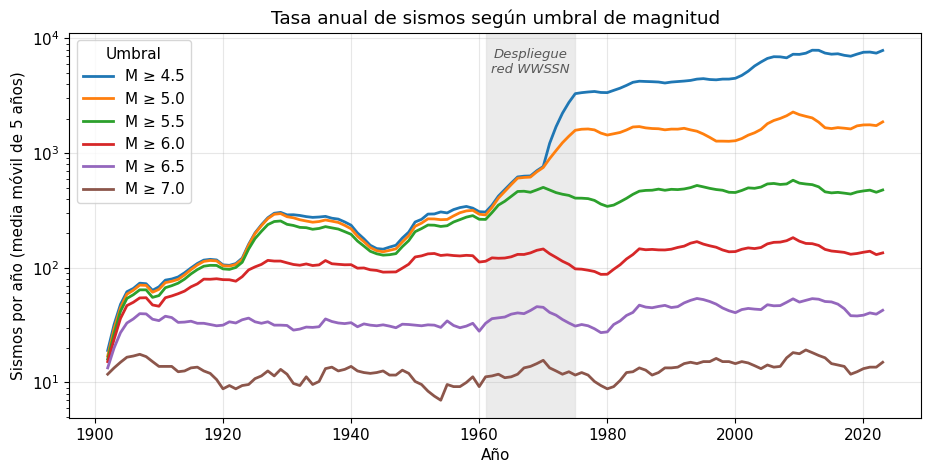

In [34]:
umbrales = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
anios = np.arange(1900, 2026)

fig, ax = plt.subplots(figsize=(11,5))
for u in umbrales:
    serie = eq[eq.mag>=u].groupby('year').size().reindex(anios, fill_value=0)
    ax.plot(anios, serie.rolling(5, center=True).mean(), lw=2, label=f'M ≥ {u}')

ax.axvspan(1961, 1975, color='0.87', alpha=.6, zorder=0)
ax.text(1968, 5000, 'Despliegue\nred WWSSN', ha='center', fontsize=9.5,
        color='0.35', style='italic')

ax.set_yscale('log')
ax.set_xlabel('Año')
ax.set_ylabel('Sismos por año (media móvil de 5 años)')
ax.set_title('Tasa anual de sismos según umbral de magnitud')
ax.legend(title='Umbral')
ax.grid(alpha=0.3)
plt.show()

- Vemos que este gráfico de tasa anual de sismos según umbral de magnitud es el complemento perfecto al gráfico de la sección anterior, ya que mientras el otro mostraba el acumulado total de datos, este revela mucho mejor visualmente cómo cambió nuestra capacidad técnica para registrar sismos año tras año. 

  Es importante comenzar comentando la instalación de la red WWSSN (Red Sismográfica Estandarizada Mundial) en la década de 1960, la cual representó un salto tecnológico crucial en la sensibilidad de medición a nivel global, por lo cual la podriamos definir como el punto de inflexión en este registro histórico. Antes de este despliegue, resulta muy interesante notar que las curvas celeste, naranja y verde tienen un comportamiento prácticamente idéntico y se encuentran superpuestas. Esto ocurre por un claro sesgo en los datos de la época, explicado con que los instrumentos antiguos estaban "ciegos" a los sismos más leves, por lo que casi todo lo que lograban registrar correspondía a eventos de magnitud 5.5 o superior, haciendo que las cantidades parecieran ser las mismas para los tres umbrales. 
  
  Por el contrario, las curvas inferiores de color morado y café, que representan los sismos de magnitudes mayores a 6.5 y 7.0, no varían ni muestran este salto tecnológico brusco a lo largo del tiempo. La explicación a esta estabilidad es que estos terremotos liberan una cantidad de energía tan grande que siempre lograron ser detectados, incluso con los sismógrafos más simples de principios del siglo XX, confirmando que los sismos de alta intensidad se han mantenido constantes en el tiempo y que su detección no depende de nuestra capacidad instrumental.

- Ahora, buscando evolucionar la información que nos entregó el gráfico anterior, normalizaremos cada una de las curvas con su promedio correspondiente desde 1900 a 1960 (decada en la que se implementó la red), a continuación vemos lo obteido:

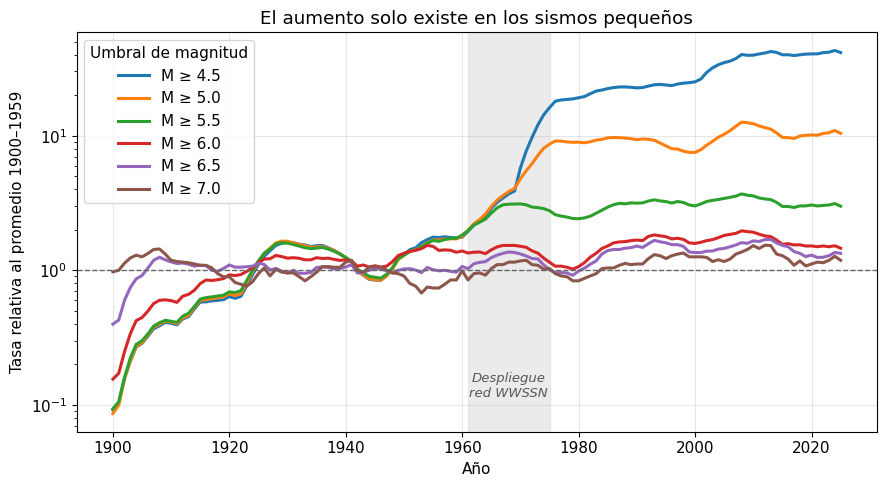

In [35]:
umbrales = [4.5,5.0, 5.5, 6.0, 6.5, 7.0]
base = (anios >= 1900) & (anios <= 1959)

fig, ax = plt.subplots(figsize=(9, 5))
for u in umbrales:
    s = eq[eq.mag >= u].groupby('year').size().reindex(anios, fill_value=0)
    r = (s / s[base].mean()).rolling(7, center=True, min_periods=3).mean()
    ax.plot(anios, r, lw=2.2, label=f'M ≥ {u}')


ax.axvspan(1961, 1975, color='0.87', alpha=.6, zorder=0)
ax.text(1968, 0.115, 'Despliegue\nred WWSSN', ha='center', fontsize=9.5,
        color='0.35', style='italic')
ax.axhline(1, color='0.4', ls='--', lw=1)
ax.set_yscale('log')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa relativa al promedio 1900–1959')
ax.set_title('El aumento solo existe en los sismos pequeños')
ax.legend(title='Umbral de magnitud')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Podemos ver que normalizar todas las curvas tomando el promedio correspondiente de la primera mitad del siglo como base es clave, porque nos permite comparar todo en una misma escala. Si el gráfico anterior mostraba que ahora registramos más sismos, este nos explica el porqué. Queda clarísimo que a principios de siglo los catálogos estaban "ciegos" ante sismos más suaves. Pero en los años 60, con la llegada de la nueva red mundial (la franja gris), la detección de sismos menores se dispara de golpe, registrando hasta 50 veces más eventos que antes.

Por otro lado, esto nos da una prueba directa de que el planeta se sigue comportando igual. Aunque las detecciones de temblores pequeños subieron muchísimo, las líneas de los sismos fuertes (sobre 6.5 y 7.0) no cambian con la nueva tecnología, sino que se mantienen casi planas en la marca del 1. Esto confirma que hoy tenemos la misma cantidad de sismos grandes que hace un siglo. Entonces este gráfico desmiente el mito de que "ahora hay más terremotos" y demuestra que en realidad, lo único que aumentó fue nuestra tecnología para medir los sismos mas débiles.

In [36]:
tabla = []
for d in range(1900, 2030, 10):
    s = eq[(eq.year>=d) & (eq.year<d+10)]
    n_anios = 10 if d < 2020 else 6      # la década de 2020 llega solo hasta 2025
    tabla.append({'Década': f'{d}s',
                  'Todos':  len(s)/n_anios,
                  'M≥5':   (s.mag>=5).sum()/n_anios,
                  'M≥6':   (s.mag>=6).sum()/n_anios,
                  'M≥7':   (s.mag>=7).sum()/n_anios})
tabla = pd.DataFrame(tabla).set_index('Década')

print("Factor de aumento entre la década de 1900 y la de 2020:")
print((tabla.loc['2020s'] / tabla.loc['1900s']).round(2))

Factor de aumento entre la década de 1900 y la de 2020:
Todos    165.00
M≥5       41.10
M≥6        3.80
M≥7        0.95
dtype: float64


- Los factores obtenidos anteriormente, representan por cuánto se ha multiplicado nuestra capacidad para registrar sismos desde 1900 hasta la actualidad. El factor de 165 en la categoría "Todos" indica que hoy registramos 165 veces más sismos en total (ya que los instrumentos modernos detectan movimientos mínimos que antes pasaban desapercibidos). A medida que el umbral sube, esta diferencia tecnológica se achica, ya que registramos 41 veces más sismos sobre magnitud 5, y casi 4 veces más sobre magnitud 6. Pero el dato principal es el factor de 0.95 (prácticamente 1) para los eventos mayores a 7. Este número confirma matemáticamente todo el análisis visual previo, el cual inicaba que la cantidad de grandes terremotos no se ha multiplicado en absoluto, registrando la misma cantidad hoy que hace un siglo. 

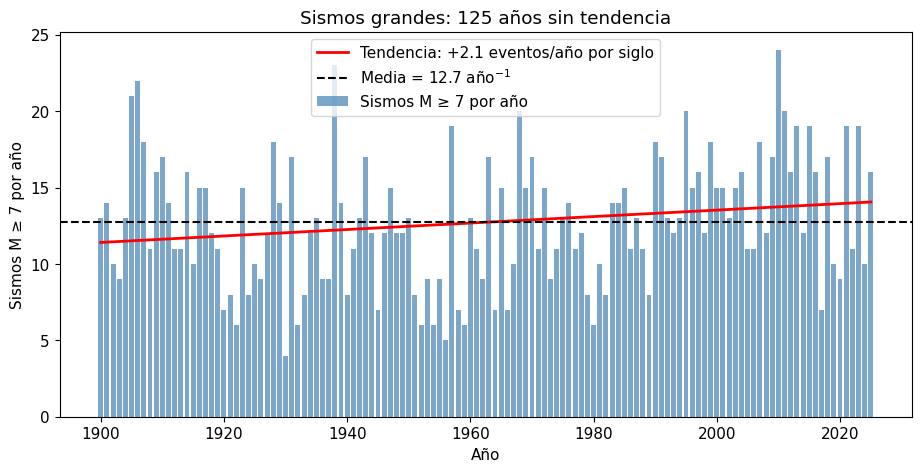

In [37]:
serie7 = eq[eq.mag>=7.0].groupby('year').size().reindex(anios, fill_value=0)
pend, cte = np.polyfit(anios, serie7.values, 1)

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(anios, serie7.values, color='steelblue', alpha=0.7, label='Sismos M ≥ 7 por año')
ax.plot(anios, np.polyval([pend,cte], anios), 'r-', lw=2,
        label=f'Tendencia: {pend*100:+.1f} eventos/año por siglo')
ax.axhline(serie7.mean(), color='k', ls='--', lw=1.5,
           label=f'Media = {serie7.mean():.1f} año$^{{-1}}$')
ax.set_xlabel('Año')
ax.set_ylabel('Sismos M ≥ 7 por año')
ax.set_title('Sismos grandes: 125 años sin tendencia')
ax.legend()
plt.show()


- A diferencia del análisis de los gráficos anteriores, aquí nos enfocamos exclusivamente en los sismos mayores a 7.0. Como ya vimos, el registro de estos sismos grandes nunca dependió de mejoras tecnológicas, debido a que su enorme energía liberada siempre garantizó que fueran detectados. Al aislar esta categoría comprobamos que el ritmo de la Tierra es sumamente constante, oscilando en torno a un promedio histórico estable de 12.7 grandes terremotos por año.

- Aunque la línea roja muestra una leve tendencia al alza a lo largo del tiempo, este pequeño aumento es insignificante. El gráfico demuestra que la actividad sísmica de alta magnitud funciona alternando décadas "tranquilas" con periodos donde se presencian una mayor cantidad de sismos, pero estas alzas y bajas son fluctuaciones completamente normales de las placas tectónicas, reafirmando de forma definitiva que no vivimos en un planeta cada vez más sísmico.

---

## 6. Contexto geográfico

Hasta ahora miramos bastantes caracteristicas del catálogo. Pero los sismos no ocurren en cualquier sitio, sino en los bordes de las placas, y cada una de esas zonas tiene una historia en el sentido de a cuando se instalaron sismógrafos ahí.

Asi que observamos distintas zonas sismicas.

In [38]:
def clasificar_region(lat, lon):
    if -60 <= lat <= 15  and -85 <= lon <= -60:           return 'Sudamérica (Andes)'
    if  25 <= lat <= 50  and 125 <= lon <= 150:           return 'Japón'
    if  50 <= lat <= 72  and (lon <= -130 or lon >= 170): return 'Alaska–Aleutianas'
    if -12 <= lat <= 8   and  92 <= lon <= 142:           return 'Indonesia'
    if -40 <= lat <= -10 and (lon >= 170 or lon <= -170): return 'Fiji–Tonga–Kermadec'
    if  30 <= lat <= 45  and -125 <= lon <= -115:         return 'California'
    return None

eq['region'] = [clasificar_region(a, b) for a, b in zip(eq.latitude, eq.longitude)]
print(eq.region.value_counts())

region
Indonesia              46053
Fiji–Tonga–Kermadec    40249
Japón                  27969
Sudamérica (Andes)     24794
Alaska–Aleutianas      10214
California              2038
Name: count, dtype: int64


- Como se puede notar tenemos 6 regiones en donde ocurrieron sismos. Usaremos está información para ver si las detecciones varían en el tiempo.

In [39]:
periodos = [(1900,1959), (1960,1979), (1980,1999), (2000,2025)]
regiones = ['California', 'Alaska–Aleutianas', 'Japón',
            'Sudamérica (Andes)', 'Indonesia', 'Fiji–Tonga–Kermadec']

filas = []
for r in regiones:
    s = eq[eq.region == r]
    fila = {'Región': r}
    for lo, hi in periodos:
        sub = s[(s.year>=lo) & (s.year<=hi)]
        fila[f'{lo}–{hi}'] = len(sub)/(hi-lo+1)
    fila['Factor'] = fila['2000–2025'] / fila['1900–1959']
    filas.append(fila)

comp = pd.DataFrame(filas).set_index('Región')
display(comp.round(1))

,1900–1959,1960–1979,1980–1999,2000–2025,Factor
Región,,,,,
California,15.4,13.6,24.4,13.5,0.9
Alaska–Aleutianas,10.6,76.3,183.2,168.8,15.9
Japón,17.6,162.9,384.2,614.2,34.8
Sudamérica (Andes),9.0,150.6,343.0,553.1,61.1
Indonesia,13.4,178.8,657.3,1097.2,81.8
Fiji–Tonga–Kermadec,9.0,168.5,502.6,1011.0,112.3


- Cada una de las celdas es el promedio de sismos por año que se registraron en cada región durante ese intervalo de tiempo y la ultima celda divide el período más reciente por el más antiguo.

- El factor indica que tanto ha cambiado en el tiempo, y podemos notar que California es el que menos cambió entre todas ellas, de hecho no cambió. Mientras que en Fiji-Tonga hubo un factor de 112 veces más la cantidad de sismos registrados.

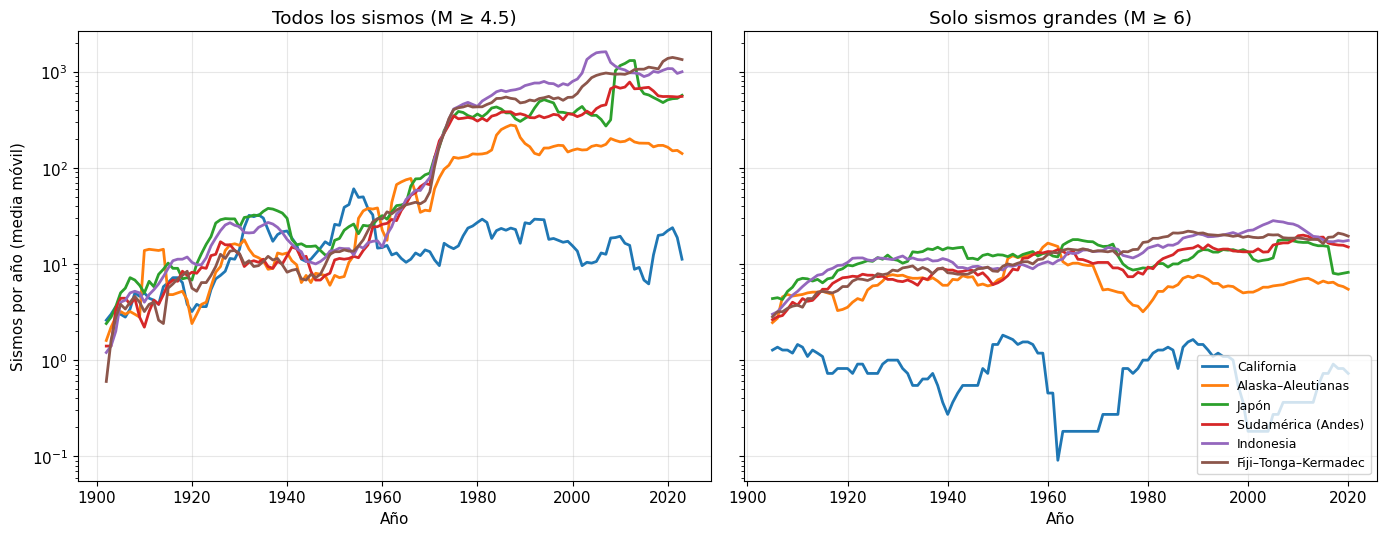

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5), sharey=True)

for r, c in zip(regiones, plt.cm.tab10.colors):
    s = eq[eq.region==r].groupby('year').size().reindex(anios, fill_value=0)
    axes[0].plot(anios, s.rolling(5, center=True).mean(), lw=2, color=c, label=r)
    s6 = eq[(eq.region==r) & (eq.mag>=6)].groupby('year').size().reindex(anios, fill_value=0)
    axes[1].plot(anios, s6.rolling(11, center=True).mean(), lw=2, color=c, label=r)

for ax, t in zip(axes, ['Todos los sismos (M ≥ 4.5)', 'Solo sismos grandes (M ≥ 6)']):
    ax.set_yscale('log')
    ax.set_xlabel('Año')
    ax.set_title(t)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Sismos por año (media móvil)')
axes[1].legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

- En el panel izquierdo, con todos los sismos, las curvas empiezan juntas y se separan con los años. En el panel derecho, se consideran los sismos de magnitud 6 o mayor y se puede notar que se mantienen mucho más parejas durante los años.

- Como se puede notar, tal como se observó en la tabla, california en ambos graficos no tiene un aumento muy contundente en cantidad de sismos, Y esto es probablemente a que en esta región tenían una detección mejor en años antiguos en comparación a las otras regiones.

- De todas formas podemos notar algo interesante y es que claramente se puede notar que hay un leve aumento en el panel derecho para las curvas superiores a california. Y esto significa que en esas zonas el catalogo antiguo estaba incompleto incluso en magnitudes de rango 6-6.9. Cosa que se veía en los analisis anteriores cuando se veían los factores por los que aumentaban las detecciones.

---
## 7. Los eventos extremos llegan al azar?

Las secciones anteriores nos mostraron que sobre M = 6.0 o 6.5 el catalogo de terremotos es homogéneo en el tiempo. Eso nos permite mirar el extremo superior del registro (el homogéneo) usando los 125 años completos, para que las conclusiones sean independientes de la época en que ocurrió cada evento.

In [41]:
mega = eq[eq.mag >= 8.5].sort_values('time')
t_mega = (mega.time.dt.year + mega.time.dt.dayofyear/365.25).values

print(f"Megaterremotos (M ≥ 8,5) en 1900–2025: {len(mega)}")
print(f"Tasa media: {len(mega)/126:.2f} por año")
print(f"Rango de profundidad: {mega.depth.min():.0f} – {mega.depth.max():.0f} km  (todos superficiales)")
print(f"Escalas de magnitud usadas: {list(mega.magType.unique())}")
print(f"\nAños transcurridos entre eventos consecutivos:")
print(np.round(np.diff(t_mega), 1))

display(mega[['time','mag','depth','place']].reset_index(drop=True))

Megaterremotos (M ≥ 8,5) en 1900–2025: 17
Tasa media: 0.13 por año
Rango de profundidad: 15 – 70 km  (todos superficiales)
Escalas de magnitud usadas: ['mw', 'mww']

Años transcurridos entre eventos consecutivos:
[16.8 15.2  8.2  4.4  2.2  4.3  3.2  3.4  0.5  0.9 39.9  0.2  4.9  1.
  1.1 13.3]


,time,mag,depth,place
0,1906-01-31 15:36:10+00:00,8.8,20.0,1906 Ecuador-Colombia Earthquake
1,1922-11-11 04:32:51+00:00,8.5,70.0,"94 km ENE of Vallenar, Chile"
2,1938-02-01 19:04:22+00:00,8.5,25.0,1938 Banda Sea Earthquake
3,1946-04-01 12:29:01+00:00,8.6,15.0,"The 1946 Unimak Island, Alaska Earthquake"
4,1950-08-15 14:09:34+00:00,8.6,15.0,1950 Assam-Tibet Earthquake
5,1952-11-04 16:58:30+00:00,9.0,21.6,"89 km ESE of Petropavlovsk-Kamchatsky, Russia"
6,1957-03-09 14:22:33+00:00,8.6,25.0,"1957 Atka, Alaska Earthquake"
7,1960-05-22 19:11:20+00:00,9.5,25.0,1960 Great Chilean Earthquake (Valdivia Earthq...
8,1963-10-13 05:17:59+00:00,8.5,35.0,1963 Kuril Islands Earthquake
9,1964-03-28 03:36:16+00:00,9.2,25.0,"The 1964 Prince William Sound, Alaska Earthquake"


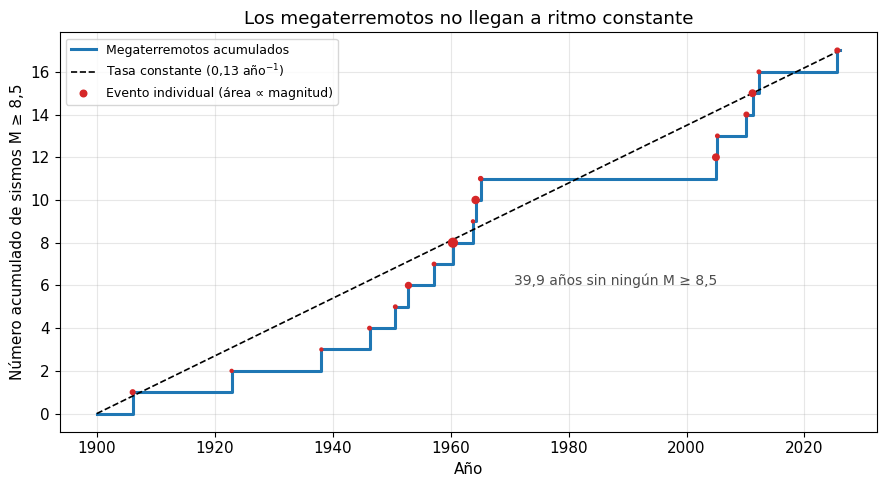

In [42]:
fig, ax = plt.subplots(figsize=(9,5))
ax.step(np.r_[1900, t_mega, 2026], np.r_[0, np.arange(1,len(t_mega)+1), len(t_mega)],
        where='post', lw=2.2, color='tab:blue', label='Megaterremotos acumulados')
ax.plot([1900,2026], [0,len(t_mega)], 'k--', lw=1.2,
        label='Tasa constante (0,13 año$^{-1}$)')
ax.scatter(t_mega, np.arange(1,len(t_mega)+1), s=18*(mega.mag.values-8)**2,
           color='tab:red', zorder=3, label='Evento individual (área ∝ magnitud)')
ax.annotate('39,9 años sin ningún M ≥ 8,5', xy=(1988, 6), ha='center', fontsize=10, color='0.3')

ax.set_yticks(range(0,18,2))
ax.set_xlabel('Año')
ax.set_ylabel('Número acumulado de sismos M ≥ 8,5')
ax.set_title('Los megaterremotos no llegan a ritmo constante')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
intervalos = np.diff(t_mega)

print(f"Intervalo medio entre megaterremotos: {intervalos.mean():.1f} años")
print(f"Intervalo más corto: {intervalos.min():.1f} años")
print(f"Intervalo más largo: {intervalos.max():.1f} años  "
      f"({intervalos.max()/intervalos.mean():.1f} veces el promedio)")

Intervalo medio entre megaterremotos: 7.5 años
Intervalo más corto: 0.2 años
Intervalo más largo: 39.9 años  (5.3 veces el promedio)


### Un resultado inesperado

**Observación.** 

Los megaterremotos no se distribuyen de manera uniforme en el tiempo. Como se observa en el gráfico anterior, entre 1950 y 1965 aprox. ocurrieron siete eventos M ≥ 8.5, incluyendo los mayores jamás registrados (Valdivia 1960 (M 9.5) y Alaska (M 9.2)). Después el planeta pasó casi 40 años sin un solo megaterremoto, hasta Sumatra 2004. Luego vinieron 5 de estos megaterremotos en ocho años y el más reciente en 2025.

El intervalo medio entre estos sismos gigantes es de 7.5 años, pero los extremos de estos intervalos son el más pequeño siendo de 0.2 años hasta el más grande siendo de 39.9 años, o sea, es ~5 veces el promedio. La figura anterior de sismos acumulados muestra este comportamiento ya que las líneas horizontales nos muestran las mesetas que se generan a lo largo del tiempo respecto a estos grandes sismos. Donde se ve claramente una línea horizontal extensa que denota estos 40 años sin megaterremotos.

No se esperaba que después de notar que la sismicidad global es bastante estable a lo largo de los años, se encontrara que los eventos más grandes llegan en tandas. Por lo tanto se generó una hipótesis 


**Hipótesis.** 

Básicamente, hay dos posibles explicaciones para esto, pero con los datos que tenemos no es posible asegurar cuál es la correcta:

1. Es solo azar. Como apenas tenemos 17 eventos en 125 años, puede que algunas coincidencias generen estas mesetas y tandas sin que haya realmente un mecanismo físico detrás.

2. Existe una interacción física. Un megaterremoto cambia y redistribuye las tensiones en la corteza terrestre, lo que de alguna forma podría favorecer a que ocurran otros megaterremotos haciendo que vengan en grupos.

**Información que necesitaríamos saber.** 

Principalmente, tener un registro mucho más largo. Cosas como la paleosismología (ciencia que estudia los terremotos del pasado) nos podrían ayudar a reconstruir miles de años de sismos. Solo así podríamos comprobar si este patrón de tandas realmente se mantiene en el tiempo o si los últimos 125 años fueron solo una coincidencia.



### Qué responde esto de nuestra pregunta

La segunda parte de nuestra pregunta apuntaba a ver si estos megaterremotos se agrupan de alguna manera que nos permita predecirlos un poco. La conclusión es que se nota un agrupamiento, pero no nos sirve para predecir nada.

Se puede decir que los sismos grandes llegan en tandas según el gráfico, pero no tenemos cómo saber si esto pasa por un mecanismo físico real o si es solo algo irregular de eventos que ocurren muy poco. Y mucho menos nos sirve como para predecir cuándo o dónde va a ser el próximo gran sismo. Al final solo tenemos 17 eventos registrados, por más vueltas que le demos, no vamos a poder superar esta limitación.

---
## 8. Figura clave

In [44]:
eq['M0'] = 10**(1.5*eq.mag + 9.1)      # momento sísmico [N m]

umbral = 7.0                            # ajustable
E = (eq[eq.mag >= umbral].groupby('year').M0.sum()
       .reindex(anios, fill_value=0) / 1e21).values

### Cómo pasamos de magnitud a energía


La magnitud de un sismo no es una medida directa de su tamaño, es una escala logarítmica. Para poder trabajar con lo que la magnitud provoca, o sea, la energía liberada se usa el momento sísmico, que sí es una cantidad física, y que se obtiene de la magnitud con la siguiente relación: 

$$\log_{10}(M_0) = 1{,}5\,M + 9{,}1$$

donde $M_0$ está en newton-metro. Lo importante de esta fórmula es el 1,5 del exponente, esto significa que cada punto de magnitud multiplica la energía liberada por unas 32 veces. O sea que, un sismo de magnitud 6 no es un poco más grande que uno de 5, libera 32 veces más energía y entre un magnitud 5 y un magnitud 9 es 32^4 ~ 1.000.000 veces más energetico

Por esos mismo contar sismo y medir energía son dos cosas muy distintas, un solo evento gigante puede pesar mucho más que miles de sismos medianos juntos.

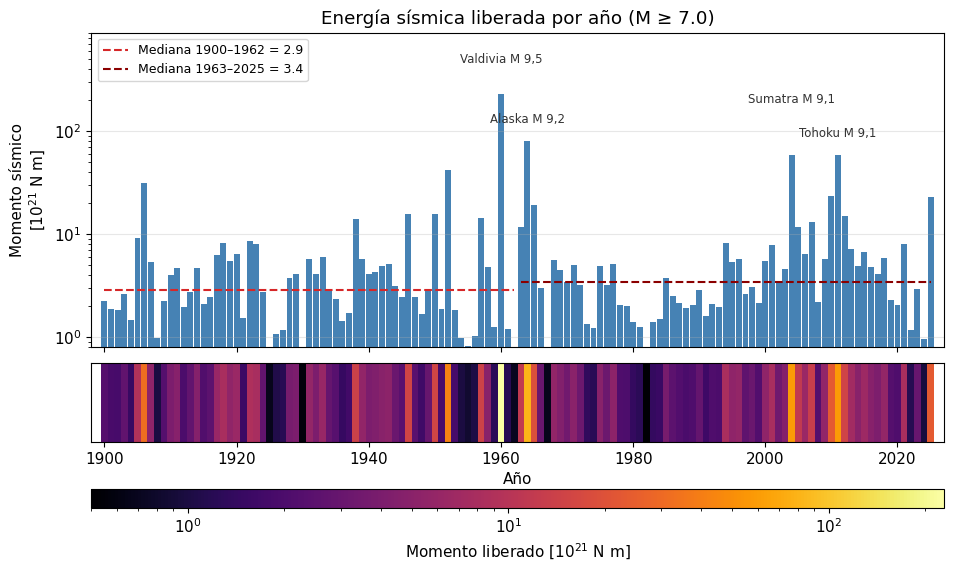

In [45]:
from matplotlib.colors import LogNorm

umbral = 7.0
E = (eq[eq.mag >= umbral].groupby('year').M0.sum()
       .reindex(anios, fill_value=0) / 1e21).values

norm = LogNorm(vmin=0.5, vmax=E.max())
cmap = plt.cm.inferno

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True,
                               gridspec_kw={'height_ratios':[4,1], 'hspace':0.08,
                                            'bottom':0.26})

#panel superior
ax1.bar(anios, E, color='steelblue', width=0.9)
ax1.set_yscale('log')
ax1.set_ylim(0.8, 900)
med1, med2 = np.median(E[:63]), np.median(E[63:])
ax1.hlines(med1, 1900, 1962, color='tab:red',  ls='--', lw=1.5,
           label=f'Mediana 1900–1962 = {med1:.1f}')
ax1.hlines(med2, 1963, 2025, color='darkred', ls='--', lw=1.5,
           label=f'Mediana 1963–2025 = {med2:.1f}')

for a, txt, f in [(1960,'Valdivia M 9,5',2.0), (1964,'Alaska M 9,2',1.5),
                  (2004,'Sumatra M 9,1',3.2), (2011,'Tohoku M 9,1',1.5)]:
    ax1.annotate(txt, xy=(a, E[a-1900]), xytext=(a, E[a-1900]*f),
                 ha='center', fontsize=8.5, color='0.2')

ax1.set_ylabel('Momento sísmico\n[10$^{21}$ N m]')
ax1.set_title(f'Energía sísmica liberada por año (M ≥ {umbral})')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3, axis='y')

#panel inferior 
m = ax2.pcolormesh(np.r_[anios, 2026]-0.5, [0,1], E[None,:], cmap=cmap, norm=norm)
ax2.set_yticks([])
ax2.set_xlabel('Año')
ax2.set_xlim(1898, 2027)

pos = ax2.get_position()
cax = fig.add_axes([pos.x0, pos.y0 - 0.1, pos.width, 0.028])
cb  = fig.colorbar(m, cax=cax, orientation='horizontal')
cb.set_label('Momento liberado [10$^{21}$ N m]')

plt.show()

In [46]:
tot = eq.M0.sum()
print(f"Valdivia aporta el {100*eq.M0.max()/tot:.0f}% del momento total")
print(f"Los 17 megaterremotos (M≥8,5): {100*eq[eq.mag>=8.5].M0.sum()/tot:.0f}%")
print(f"Todos los sismos bajo M 7: {100*eq[eq.mag<7].M0.sum()/tot:.0f}%")

Valdivia aporta el 20% del momento total
Los 17 megaterremotos (M≥8,5): 53%
Todos los sismos bajo M 7: 8%


### Por qué esta es nuestra figura clave

**¿Qué pregunta responde?** 

Básicamente, si la Tierra está liberando más energía ahora que antes. Contar la cantidad de sismos tiene el problema de que depende mucho de los instrumentos y de cuántos logremos detectar. Pero la energía liberada no funciona de esta manera, la mayor parte de la energía viene de los terremotos gigantes, y esos se registraban igual de bien en 1900 que hoy. Por esta razón, este gráfico nos muestra la actividad sísmica real y no simplemente que ahora tenemos mejores instrumentos de detección.

**¿Qué patrón vemos?** 

Principalmente dos cosas.

Primero que las medianas son casi iguales, 2.9 antes del 62 y 3.4 después. O sea, que en 125 años la energía que libera la Tierra no ha cambiado mucho, a pesar de que el número de sismos del catálogo haya aumentado exageradamente después de los 60s.

Segundo, que la liberación de energía es súper irregular. La mediana anual está alrededor de 3.0 pero el valor más alto llega a 229. Estos peaks enormes corresponden a solo eventos de gran magnitud, como Valdivia, Alaska o Tohoku, y entremedio de algunos eventos quedan intervalos más planos en el gráfico. Para entender un poco la magnitud solo Valdivia representa el 20% de toda la energía liberada en esos 125 años, y los 17 megaterremotos sumados son más del 50% de esa energía total. En cambio, todos los sismos menores a 7.0 solo tienen una contribución del 8% (considerar que estos son casi el 99% de los datos).


**¿Por qué es importante?** 


Porque si solo miramos la cantidad de sismos, pareciera que hoy tiembla muchísimo más que antes. Pero si lo medimos en energía, la verdad es que no ha sucedido nada extraño en 125 años. Queda claro que el catálogo de sismos creció gracias a temblores que no aportan mucha energía.

Aparte, esto se conecta con lo que veíamos en la sección anterior, donde esos años planos en el gráfico son exactamente los mismos huecos sin megaterremotos que mencionábamos antes.

**Decisiones sobre el diseño.**

Tuvimos que usar escala logarítmica sí o sí porque los valores abarcan tres órdenes de magnitud. La franja de abajo repite los mismos datos pero con colores, lo que ayuda a visualizar mejor bloques enteros de años en vez de estar mirando barra por barra. Además, pusimos un corte en M >= 7 para dejar las magnitudes de los sismos más chicos, ya que son ínfimos transformados a energía y de todas formas representan menos del 10% del total de energía.

---
## 9. Respuesta al desafío inicial

**¿Podemos afirmar, a partir de estos datos, que últimamente está temblando más?**


Básicamente no, simplemente se están registrando más, pero no está temblando más. Y hay cuatro evidencias que apuntan a esto:

1. Si se miran solo los sismos grandes se puede notar una tasa uniforme. Al contar todos los sismos se puede ver que hay un aumento exagerado con respecto a los inicios de las detecciones. Pero si se filtran los de magnitudes mayores a 7, no hay un aumento importante como sí lo hay con los de menores magnitudes. Si la Tierra estuviese de verdad más activa, se tendría que notar este efecto en todas las magnitudes.

2. La forma de la distribución de magnitudes no ha cambiado. Si se superponen las curvas de cuatro épocas, vemos que solo se separan en las magnitudes bajas, pero calzan muy bien en las magnitudes altas. Lo único que sucedió es que el límite de detección cambió con el pasar de los años. Todos los sismos que "aparecieron" en las curvas recientes siempre estuvieron ahí, solo que antes no se registraban.

3. El aumento va acorde a dónde se pusieron instrumentos de medición. Por ejemplo, si revisamos el gráfico que ve curvas por zona. Las regiones que muestran el mayor crecimiento sísmico son las que tenían peores instrumentos en 1900. No hay ninguna razón geológica para que un supuesto aumento global de sismos no afecte justo a la única zona que ya estaba bien observada hace un siglo.

4. Si medimos la energía podemos ver que no ha pasado nada. La mediana de la energía liberada por año es de 2.9 antes del 62 y 3.4 después. Esta es la evidencia más directa, porque la energía casi siempre la aportan los eventos grandes, y esos no se escapaban ni siquiera con los instrumentos antiguos.


### Qué no podemos asegurar

Con esto no podemos descartar que existan variaciones reales pequeñas. Ya que analizamos las cosas a una escala más grande.

Tampoco podemos decir mucho de los sismos que son menores a 4.5 porque directamente los cortamos de nuestro análisis.

Y por último, respecto a los megaterremotos, ya vimos que sí, según el gráfico llegan en tandas. Pero, al final 17 eventos es una muestra muy chica como para saber si esa agrupación es por una causa física, o si es simplemente lo que pasa por azar.

---
## 10. Conclusión


En resumen, el catálogo del USGS entre 1900 a 2025 tiene alrededor de 300.000 sismos de magnitud 4.5 o más. Y aunque la cantidad que se registra cada año ha crecido en todo este tiempo, todo nuestro análisis nos lleva a una idea. Este aumento cuenta cómo se ha ido mejorando la red de instrumentación de detecciones de sismos, no la historia física de estos.

Hay tres cosas bastante claras que nos demuestra esto. Primero, el supuesto aumento de la sismicidad desaparece a medida que miramos magnitudes más altas, desapareciendo por completo en las magnitudes mayores a 7. Segundo, el "crecimiento" se concentra justo en las zonas que se vigilaban peor hace un siglo. Y tercero, este salto calza justo con la instalación de la red mundial de sismógrafos en los años 60. Si observamos la distribución de magnitudes acumulada, la forma se mantuvo intacta durante todo el siglo, lo único que realmente se movió fue nuestra capacidad de detectar los terremotos de más baja magnitud.

Si en vez de contar sismos medimos la energía liberada, la cosa queda aún más clara. La mediana anual de energía es prácticamente igual en la primera y en la segunda mitad del siglo. Los únicos que realmente aumentaron los registros fueron los sismos chicos, que si se suman todos, no alcanzan a tener una contribución más grande del 10% para la energía total.

Ahora bien, esta estabilidad se nota en los promedios. Cuando nos vamos a los megaterremotos, podemos ver que llegan en tandas, hubo siete entre 1950 y 1965, luego casi 40 años de "vacío" de megaterremotos, y después cinco más entre 2004 y 2012. Como mencionamos antes, no pudimos definir si esto pasa por un mecanismo físico o si es lo esperable en la estadística de una situación que ha ocurrido solo 17 veces a lo largo de 125 años. Lo que sí es seguro es que la energía sísmica del planeta la deciden unos pocos eventos rarísimos. Basta ver que Valdivia 1960 por sí sola aporta la quinta parte de toda la energía liberada en el siglo.

Lo importante que sacar de todo esto es que un catálogo de observaciones no es un reflejo exacto de lo que pasó, sino de lo que fuimos capaces de ver. Lo que a simple vista parecía ser la tendencia más impresionante de los datos resultó ser solo una propiedad de nuestros propios instrumentos.

---
## 11. Posible problema de Machine Learning

**¿Qué intentaríamos predecir?** 

La idea sería responder esto, "dado que acaba de ocurrir un sismo de magnitud M ≥ 6, ¿qué probabilidad hay de que le siga otro evento igual o mayor en los próximos 30 días en un radio de 200 km?" En el fondo se quiere clasificar si ese temblor es un evento independiente o si es el detonante de algo más.

**¿Por qué enfocarnos en esto y no en predecir el próximo megaterremoto?**

Básicamente, porque el EDA ya nos dejó claro que esto es imposible. Con apenas 17 megaterremotos en 125 años, simplemente no tenemos una muestra decente para entrenar nada. En cambio, sismos M ≥ 6 tenemos miles.

**El modelo y features de entrada:**
Estaríamos en un problema de clasificación binaria, si hubo o no hubo otro evento fuerte después. Para armar nuestro target, tendríamos que barrer el catálogo sismo por sismo y programar una revisión de lo que pasó después en las cercanías de cada evento.

Como variables de entrada usaríamos: la magnitud, la profundidad, las coordenadas de latitud y longitud, la región, y un conteo de cuántos sismos ocurrieron en esa misma zona durante el último año para medir qué tan activa venía la falla.




**¿Qué vimos en el EDA que nos hace pensar que esto tiene futuro?**

Vimos que los eventos más masivos son todos superficiales y que la profundidad actúa como un limitante de la magnitud máxima. Es súper razonable pensar que la profundidad también juegue un rol importante en si un sismo logra generar réplicas fuertes o no. Además, si se filtra el catálogo desde 1980 como se puede ver más abajo, vemos que un 23% de los sismos M ≥ 6 tuvieron otro evento similar cerca en ese margen de 30 días. O sea, es un fenómeno que sucede y es relativamente frecuente y tendríamos una buena cantidad de ejemplos de ambas clases para entrenar.


**Dificultades que se tienen que anticipar:**



- **Clases desbalanceadas**, hay 23% frente a 77%, igual nos obligaría a usar métricas de evaluación más robustas y no fiarnos ciegamente del accuracy.

- **El sesgo de detección nos ensucia las etiquetas**, si en alguna época o lugar la detección era deficiente, un sismo podría quedar etiquetado como "sin réplica" cuando en realidad sí las tuvo pero no fueron registradas. Para no estar afectados por esto, se tendría que entrenar el modelo con eventos después de 1980, donde sabemos que el catálogo es parejo y confiable para M ≥ 4.5.

- **Faltan réplicas chicas**, como nuestro catálogo corta en la magnitud 4.5, solo estamos viendo la punta del iceberg de cada secuencia.

In [47]:
# ¿Qué tan frecuente es que un sismo grande venga acompañado de otro cerca?
# Esto define la variable objetivo de la propuesta de ML.
reciente = eq[eq.year >= 1980].sort_values('time')
lat = reciente.latitude.values
lon = reciente.longitude.values
t   = reciente.time.values.astype('datetime64[s]').astype(float) / 86400   # días
mag = reciente.mag.values

grandes = np.where(mag >= 6.0)[0]
con_secuencia = 0

for i in grandes:
    d  = np.sqrt(((lat-lat[i])*111)**2 + ((lon-lon[i])*111*np.cos(np.radians(lat[i])))**2)
    dt = t - t[i]
    if ((d < 200) & (dt > 0) & (dt <= 30) & (mag >= 6.0)).any():
        con_secuencia += 1

print(f"Sismos M ≥ 6 desde 1980: {len(grandes)}")
print(f"Seguidos por otro M ≥ 6 (30 días, 200 km): {con_secuencia} "
      f"({100*con_secuencia/len(grandes):.1f} %)")

Sismos M ≥ 6 desde 1980: 6650
Seguidos por otro M ≥ 6 (30 días, 200 km): 1554 (23.4 %)


---
## Uso de herramientas de IA

Usamos Claude (Anthropic) como apoyo para programar y depurar el código, diseñar las figuras, verificar que las cifras del texto coincidieran con las salidas, y redactar parte de las celdas de interpretación. La pregunta de investigación, las decisiones sobre qué analizar y qué descartar, y la interpretación de los resultados fueron nuestras.